In [1]:
# --- Rutas del proyecto -------------------------------------------------
# Definición única en projects/mayanlab/mayanlab/paths.py. Funciona desde
# cualquier directorio de trabajo: no hay rutas relativas en este notebook.
from pathlib import Path

from mayanlab.paths import AUDIO, ANNOTATIONS, MANIFESTS, TRANSCRIPTS, LM_TEXT, ensure, project

P = project("analysis")
FIGURES, FEATURES, PDATA = P.figures, P.features, P.data
ensure(FIGURES, FEATURES)

# MMS Dataset Analysis for Yucatec Maya

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv(PDATA / "mms_metadata.csv")
df.head(5)

,id,iso3
0,saq_122440,saq
1,mhy_203687,mhy
2,tqo_96392,tqo
3,beu_197939,beu
4,wed_09346,wed


In [4]:
df_counts = df.groupby("iso3").count().reset_index()
df_counts

,iso3,id
0,<unk>,82
1,Cameroon,1
2,Zambia,48
3,aab,1
4,aad,4
...,...,...
2807,zul,29
2808,zyg,2
2809,zyj,1
2810,zyn,11


In [5]:
df_counts["id"].max(), df_counts["id"].min()

(np.int64(257), np.int64(1))

In [6]:
def get_label_rotation(angle, offset):
    # Rotation must be specified in degrees :(
    rotation = np.rad2deg(angle + offset)
    if angle <= np.pi:
        alignment = "right"
        rotation = rotation + 180
    else: 
        alignment = "left"
    return rotation, alignment

In [7]:
def add_labels(angles, values, labels, offset, ax):
    
    # This is the space between the end of the bar and the label
    padding = 5
    
    # Iterate over angles, values, and labels, to add all of them.
    for angle, value, label, in zip(angles, values, labels):
        angle = angle
        
        # Obtain text rotation and alignment
        rotation, alignment = get_label_rotation(angle, offset)

        # And finally add the text
        ax.text(
            x=angle, 
            y=value + padding, 
            s=label, 
            ha=alignment, 
            va="center",
            rotation=rotation, 
            rotation_mode="anchor",
            fontsize=8
        )

In [8]:
df_counts = df.groupby("iso3").count().reset_index().sort_values(by="id", ascending=False)
df_counts

,iso3,id
680,eng,257
237,ben,124
509,cmn,117
2225,spa,95
1884,orc,90
...,...,...
118,aom,1
119,aon,1
1795,nms,1
1796,nmz,1


In [9]:
np.sqrt(df_counts["id"].max())

np.float64(16.0312195418814)

In [10]:
df_yua = df_counts[df_counts["iso3"] == "yua"]
df_yua

,iso3,id
2731,yua,2


In [11]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

def get_label_rotation(angle, offset):
    rotation = np.rad2deg(angle + offset)
    if angle <= np.pi:
        alignment = "right"
        rotation = rotation + 180
    else: 
        alignment = "left"
    return rotation, alignment

def add_labels(angles, values, labels, offset, ax, y_max):
    # Padding basado en Y_MAX para consistencia
    padding = y_max * 0.05  # Ajusta entre 0.1 y 0.2
    
    for angle, value, label in zip(angles, values, labels):
        rotation, alignment = get_label_rotation(angle, offset)
        
        # Color diferente para yua
        color = '#E63946' if label == 'yua' else 'black'
        weight = 'bold' if label == 'yua' else 'normal'
        
        ax.text(
            x=angle, 
            y=value + padding, 
            s=label, 
            ha=alignment, 
            va="center", 
            rotation=rotation, 
            rotation_mode="anchor",
            fontsize=6,
            color=color,
            fontweight=weight
        ) 

# ============ PARÁMETROS CONFIGURABLES ============
Y_MAX = 100
HOLE_RATIO = 0.5
SEPARATION_FACTOR = 0.85
size = 200
# ==================================================

# Calcular Y_MIN basado en la proporción deseada
Y_MIN = -Y_MAX * HOLE_RATIO

# Obtener yua
df_yua = df_counts[df_counts["iso3"] == "yua"]

# Muestreo aleatorio SIN yua
df_sin_yua = df_counts[df_counts["iso3"] != "yua"]
df_sample_random = df_sin_yua.sample(n=size-1)  # size-1 para dejar espacio a yua

# Combinar yua con el resto
df_sample = pd.concat([df_sample_random, df_yua])

# REVOLVER (shuffle) todo el DataFrame
df_sample = df_sample.sample(frac=1, random_state=123).reset_index(drop=True)

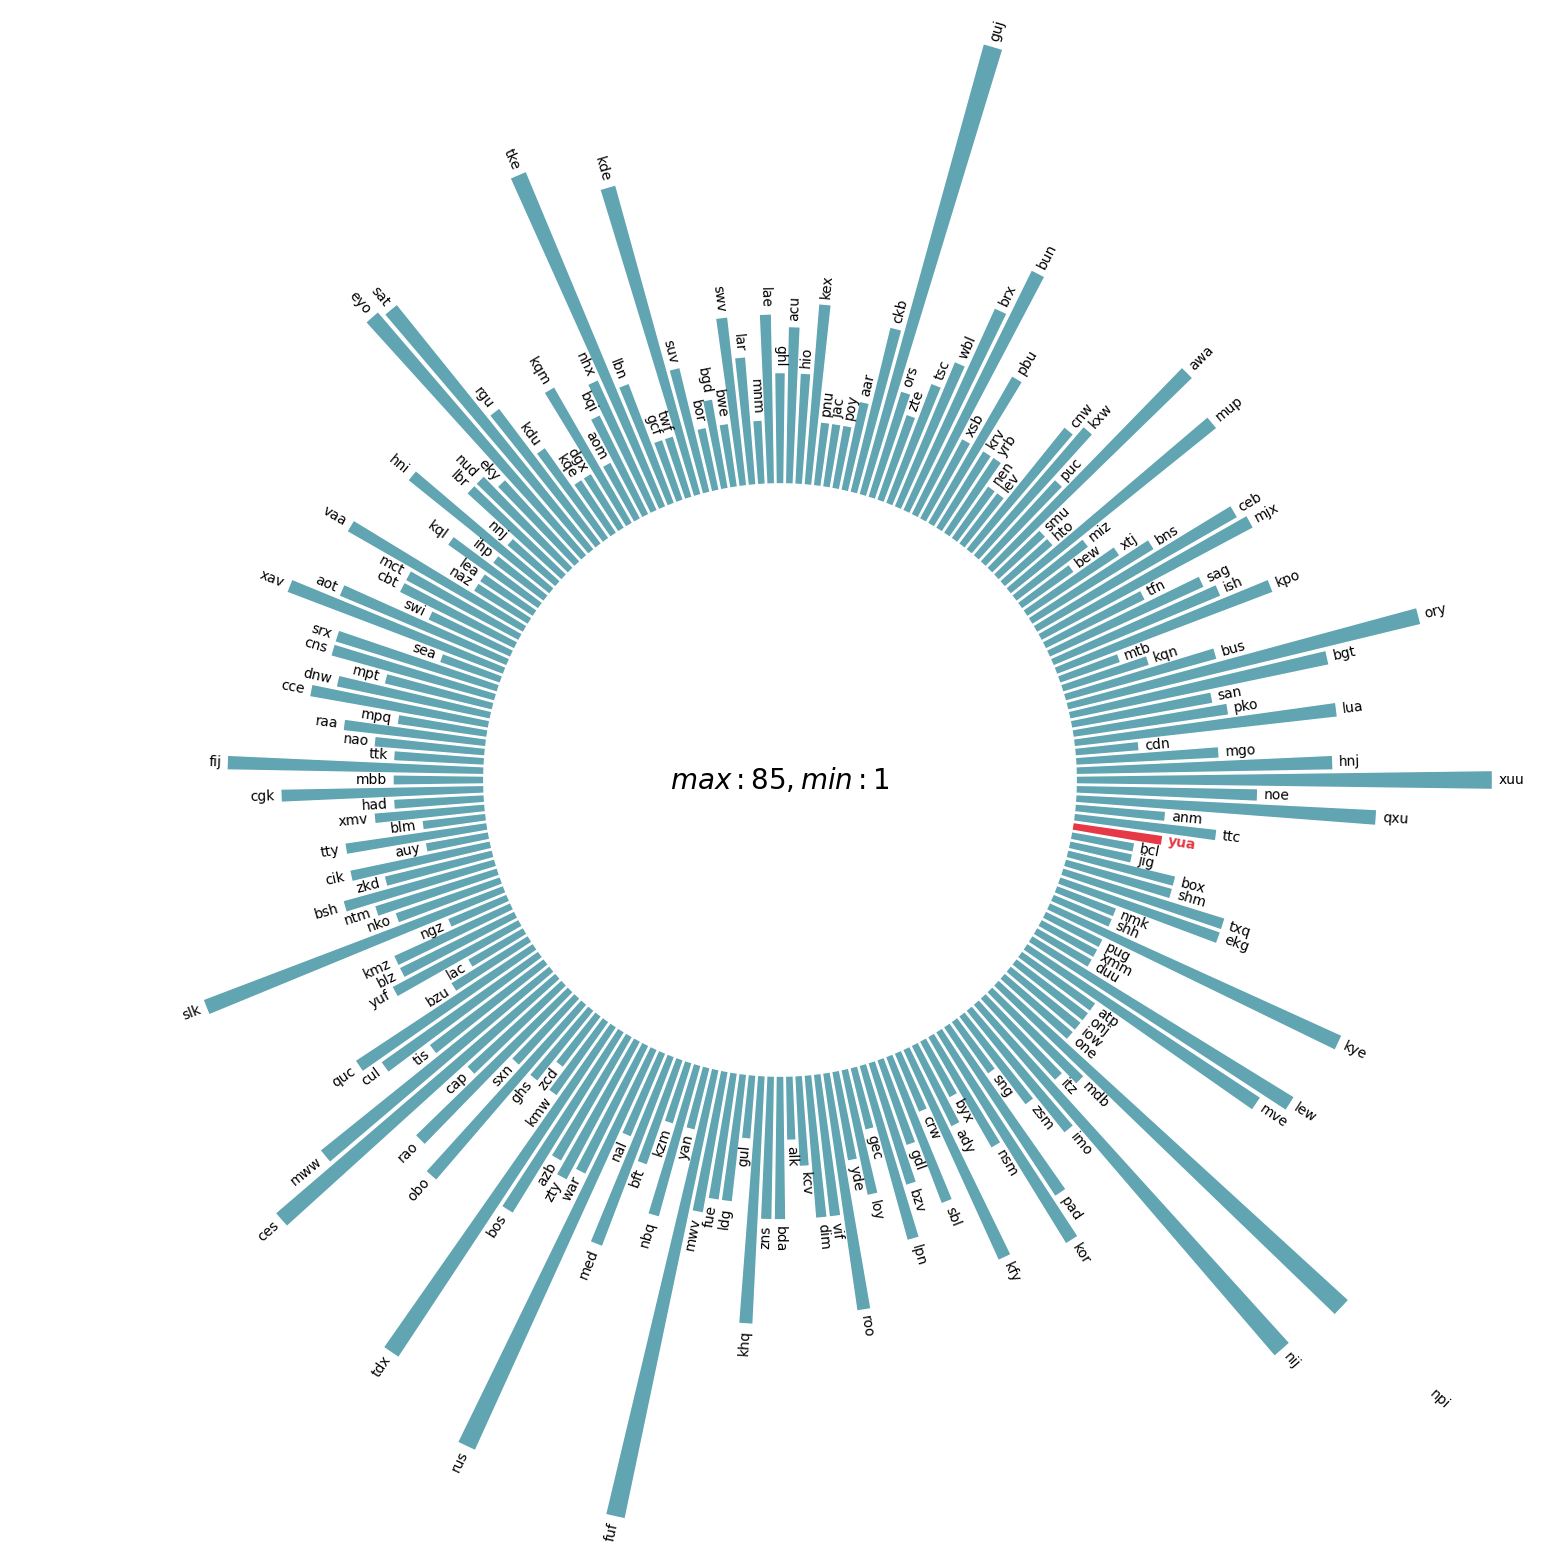

In [12]:
def add_labels(angles, values, labels, offset, ax, y_max):
    # Padding basado en Y_MAX para consistencia
    
    for angle, value, label in zip(angles, values, labels):
        padding = y_max * 0.01  # Ajusta entre 0.1 y 0.2
        rotation, alignment = get_label_rotation(angle, offset)
        
        # Color diferente para yua
        color = '#E63946' if label == 'yua' else 'black'
        weight = 'bold' if label == 'yua' else 'normal'

        if label == "xdy":
           padding = -17

        if label == "emk":
            padding = -5
        if label == "mos":
            padding = -18
        
        ax.text(
            x=angle, 
            y=value + padding, 
            s=label, 
            ha=alignment, 
            va="center", 
            rotation=rotation, 
            rotation_mode="anchor",
            fontsize=10,
            color=color,
            fontweight=weight
        ) 

VALUES_RAW = df_sample["id"].values

# Aplicar transformación de raíz cuadrada
VALUES_TRANSFORMED = np.sqrt(VALUES_RAW)

# Normalizar al rango [0, Y_MAX]
min_val = VALUES_TRANSFORMED.min()
max_val = VALUES_TRANSFORMED.max()
VALUES = VALUES_TRANSFORMED / max_val * Y_MAX

LABELS = df_sample["iso3"].values
ANGLES = np.linspace(0, 2 * np.pi, len(VALUES), endpoint=False)
WIDTH = (2 * np.pi / len(VALUES)) * SEPARATION_FACTOR
OFFSET = np.pi / 2

# Initialize Figure and Axis
fig, ax = plt.subplots(figsize=(20, 20), subplot_kw={"projection": "polar"})
ax.set_theta_offset(OFFSET)

# Límites con espacio para labels
ax.set_ylim(Y_MIN, Y_MAX * 1.25)

ax.set_frame_on(False)
ax.xaxis.grid(False)
ax.yaxis.grid(False)
ax.set_xticks([])
ax.set_yticks([])

# Crear array de colores: diferente para yua
colors = ['#E63946' if label == 'yua' else '#61a4b2' for label in LABELS]

# Add bars con colores personalizados
bars = ax.bar(
    ANGLES, VALUES, width=WIDTH, linewidth=1,
    color=colors, edgecolor="white"
)

# Add labels
add_labels(ANGLES, VALUES, LABELS, OFFSET, ax, Y_MAX)

min, max = VALUES_RAW.min(), VALUES_RAW.max()
plt.text(
    0, -50,
    rf"$max: {max}, min: {min}$",
    ha="center",
    va="center",
    fontsize=20,
)

ax.set_ylim(Y_MIN, Y_MAX * 0.8) 

fig.savefig(FIGURES / "mms-langs.png", bbox_inches='tight', pad_inches=0, dpi=300, facecolor='white')
fig.savefig(FIGURES / "mms-langs.svg", bbox_inches='tight', pad_inches=0)

plt.show()